In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset('penguins')

In [4]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

In [8]:
df = df.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']).reset_index(drop=True)

In [9]:
df. shape

(342, 7)

In [10]:
# ============================================================
# OUTLIER CHECK (IQR)
# ============================================================

In [11]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

bill_length_mm: 0 outliers
bill_depth_mm: 0 outliers
flipper_length_mm: 0 outliers
body_mass_g: 0 outliers


In [12]:
# ============================================================
# FEATURE SELECTION & SCALING
# ============================================================

In [13]:
from sklearn.preprocessing import StandardScaler

In [18]:
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[features]

# HDBSCAN is distance-based   scaling is mandatory 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

In [20]:
# ============================================================
# HDBSCAN CLUSTERING
# ============================================================

In [24]:
from sklearn.cluster import HDBSCAN

In [26]:
clusterer = HDBSCAN(min_cluster_size=10, min_samples=5)
labels = clusterer.fit_predict(X_scaled)

df['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"\nCluster sizes:\n{pd.Series(labels).value_counts().sort_index()}")

Number of clusters: 2
Number of noise points: 2

Cluster sizes:
-1      2
 0    218
 1    122
Name: count, dtype: int64


In [27]:
# ============================================================
# COMPARE CLUSTERS WITH TRUE SPECIES
# ============================================================

In [28]:
pd.crosstab(df['cluster'], df['species'])

species,Adelie,Chinstrap,Gentoo
cluster,,,
-1,0,1,1
0,151,67,0
1,0,0,122


In [31]:
# ============================================================
# VISUALIZATION (PCA 2D)
# ============================================================

In [30]:
from sklearn.decomposition import PCA

Explained variance: [0.68843878 0.19312919]
Total: 0.882


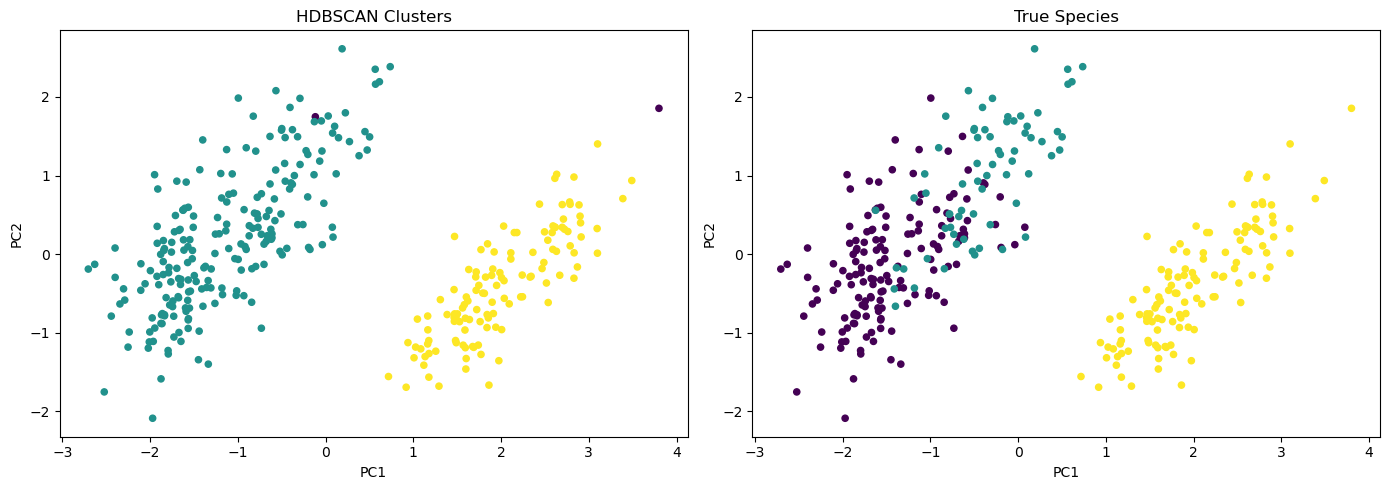

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Total: {pca.explained_variance_ratio_.sum():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=20)
axes[0].set_title('HDBSCAN Clusters')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

species_codes = df['species'].astype('category').cat.codes
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=species_codes, cmap='viridis', s=20)
axes[1].set_title('True Species')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# EVALUATION METRICS
# ============================================================

In [34]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [37]:

mask = labels != -1
X_eval = X_scaled[mask]
labels_eval = labels[mask]

sl = silhouette_score(X_eval, labels_eval)
ch = calinski_harabasz_score(X_eval, labels_eval)
db = davies_bouldin_score(X_eval, labels_eval)

print(f"Silhouette Score: {sl:.4f}")
print(f"Calinski-Harabasz Score: {ch:.2f}")
print(f"Davies-Bouldin Score: {db:.4f}")

Silhouette Score: 0.5341
Calinski-Harabasz Score: 489.11
Davies-Bouldin Score: 0.7076
